In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [37]:
df_laboral = pd.read_csv("C:/Users/brent/OneDrive/Escritorio/ProyectoImpuestos/Laboral/Archivos_exportados/tasa_empleo_total_2020_2025.csv")
df_recaudacion = pd.read_csv("C:/Users/brent/OneDrive/Escritorio/ProyectoImpuestos/Recaudacion/Archivos_exportados/recaudacion_iva_ganancias_total_2020_2025.csv")
df_pbi = pd.read_csv("C:/Users/brent/OneDrive/Escritorio/ProyectoImpuestos/Presion Tributaria/Archivos_exportados/pib_total_anual_2020_2025.csv")

In [39]:
df_laboral

,anio,tasa_informalidad,tasa_empleo_formal
0,2020,30.225,69.775
1,2021,32.575,67.425
2,2022,36.650,63.350
3,2023,36.250,63.750
4,2024,36.225,63.775
5,2025,36.900,63.100


In [41]:
df_pbi.head()

,anio,pib_total
0,2020,624591.286153
1,2021,689809.934034
2,2022,731341.633727
3,2023,717769.483211
4,2024,708130.336286


In [43]:
df_recaudacion.head()

,anio,impuesto_std,recaudacion_total
0,2020,GANANCIAS,1.302738e+06
1,2020,IVA,1.604043e+06
2,2020,TOTAL,7.607538e+06
3,2021,GANANCIAS,5.808507e+05
4,2021,IVA,9.712435e+05


In [45]:
#cambiar formato recaudacion Pero nosotros necesitamos formato ancho (wide):

#| anio | recaudacion_total | recaudacion_iva | recaudacion_ganancias |
#✅ PASO 1 — Pivotear la tabla
df_rec_pivot = df_recaudacion.pivot_table(
    index="anio",
    columns="impuesto_std",
    values="recaudacion_total",
    aggfunc="sum"
).reset_index()

df_rec_pivot

impuesto_std,anio,GANANCIAS,IVA,TOTAL
0,2020,1.302738e+06,1.604043e+06,7.607538e+06
1,2021,5.808507e+05,9.712435e+05,3.955087e+06
2,2023,1.452890e+07,2.412312e+07,8.970251e+07
3,2024,4.785621e+07,7.882915e+07,3.089811e+08
4,2025,6.757044e+07,1.115407e+08,4.214746e+08


In [47]:
#PASO 2 — Renombrar columnas
df_rec_pivot = df_rec_pivot.rename(columns={
    "TOTAL": "recaudacion_total",
    "IVA": "recaudacion_iva",
    "GANANCIAS": "recaudacion_ganancias"
})

df_rec_pivot

impuesto_std,anio,recaudacion_ganancias,recaudacion_iva,recaudacion_total
0,2020,1.302738e+06,1.604043e+06,7.607538e+06
1,2021,5.808507e+05,9.712435e+05,3.955087e+06
2,2023,1.452890e+07,2.412312e+07,8.970251e+07
3,2024,4.785621e+07,7.882915e+07,3.089811e+08
4,2025,6.757044e+07,1.115407e+08,4.214746e+08


In [49]:
#PASO 3 — Unir todo

#Primero PBI + laboral:

df_master = df_pbi.merge(
    df_laboral,
    on="anio",
    how="inner"
)


In [51]:
#Después agregamos recaudación:

df_master = df_master.merge(
    df_rec_pivot,
    on="anio",
    how="inner"
)

df_master

,anio,pib_total,tasa_informalidad,tasa_empleo_formal,recaudacion_ganancias,recaudacion_iva,recaudacion_total
0,2020,624591.286153,30.225,69.775,1.302738e+06,1.604043e+06,7.607538e+06
1,2021,689809.934034,32.575,67.425,5.808507e+05,9.712435e+05,3.955087e+06
2,2023,717769.483211,36.250,63.750,1.452890e+07,2.412312e+07,8.970251e+07
3,2024,708130.336286,36.225,63.775,4.785621e+07,7.882915e+07,3.089811e+08


In [53]:
#PASO EXTRA (MUY IMPORTANTE) Calculemos presión tributaria real:

df_master["presion_tributaria"] = (
    df_master["recaudacion_total"] / df_master["pib_total"]
) * 100

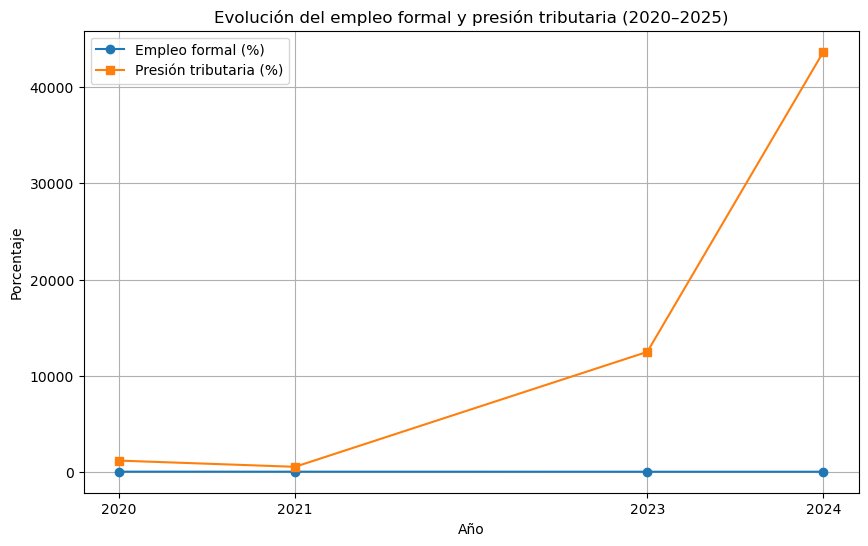

In [57]:
#📌 1) Serie temporal comparada

#Empleo formal vs. Presión tributaria (2020–2025)

plt.figure(figsize=(10,6))

plt.plot(df_master["anio"], df_master["tasa_empleo_formal"], marker="o", label="Empleo formal (%)")
plt.plot(df_master["anio"], df_master["presion_tributaria"], marker="s", label="Presión tributaria (%)")

plt.title("Evolución del empleo formal y presión tributaria (2020–2025)")
plt.xlabel("Año")
plt.ylabel("Porcentaje")
plt.grid(True)
plt.legend()
plt.xticks(df_master["anio"])
plt.show()

📌 Qué vas a observar

La caída de empleo formal en 2020 por la pandemia.

Cómo se recupera o se estanca en años siguientes.

Comparar con la evolución de la presión tributaria en el mismo periodo.

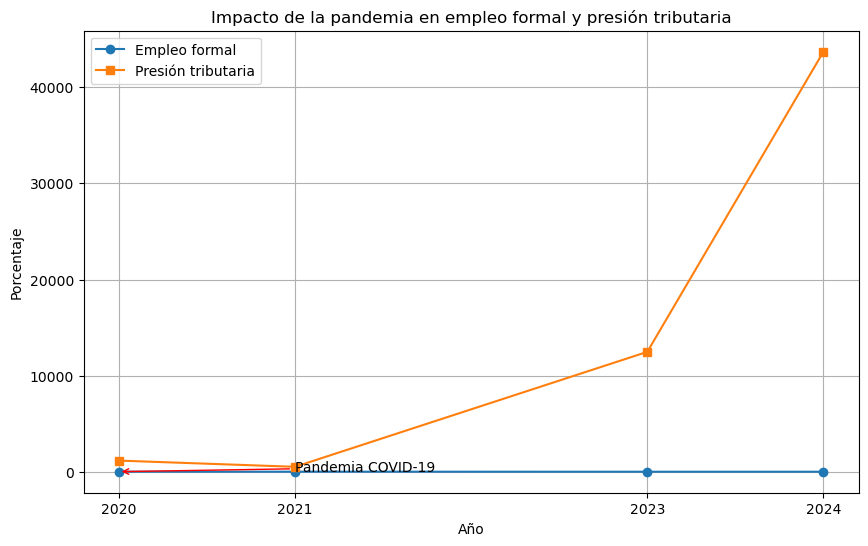

In [60]:
#📌 2) Gráfico con marcadores y anotaciones

#Enfocado en 2020 – baja formalidad y presión tributaria

plt.figure(figsize=(10,6))

plt.plot(df_master["anio"], df_master["tasa_empleo_formal"], "-o", label="Empleo formal")
plt.plot(df_master["anio"], df_master["presion_tributaria"], "-s", label="Presión tributaria")

# Anotación de pandemia
plt.annotate("Pandemia COVID-19",
             xy=(2020, df_master.loc[df_master["anio"]==2020, "tasa_empleo_formal"].values[0]),
             xytext=(2021, 75),
             arrowprops=dict(arrowstyle="->", color="red"))

plt.title("Impacto de la pandemia en empleo formal y presión tributaria")
plt.xlabel("Año")
plt.ylabel("Porcentaje")
plt.grid(True)
plt.legend()
plt.xticks(df_master["anio"])
plt.show()

🧠 Interpretación sugerida (para tu análisis)
👉 En 2020 la formalidad cae bruscamente.
👉 ¿Qué pasa con la presión tributaria ese año? ¿Hay estabilidad, caída o recuperación?

Este gráfico te permite anotar y explicar ese punto clave.

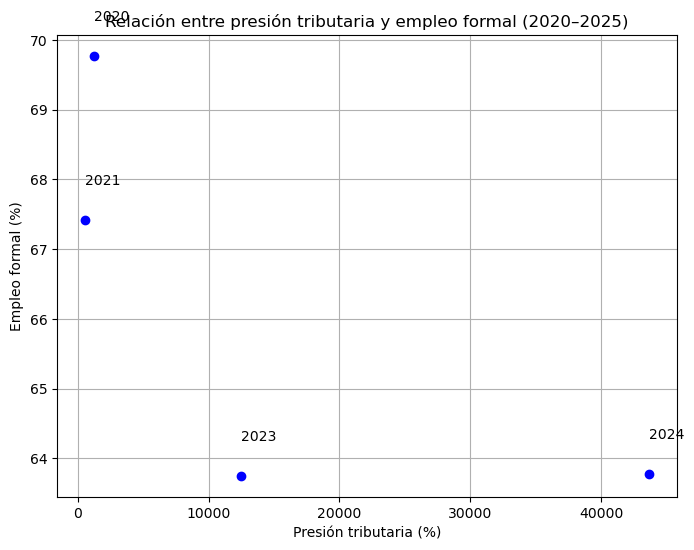

In [63]:
#📌 3) Scatter plot (dispersión)

#Relación entre presión tributaria y empleo formal

plt.figure(figsize=(8,6))

plt.scatter(df_master["presion_tributaria"], df_master["tasa_empleo_formal"], c="blue")

for i in range(len(df_master)):
    plt.text(df_master["presion_tributaria"][i]+0.05, 
             df_master["tasa_empleo_formal"][i]+0.5, 
             df_master["anio"][i])

plt.title("Relación entre presión tributaria y empleo formal (2020–2025)")
plt.xlabel("Presión tributaria (%)")
plt.ylabel("Empleo formal (%)")
plt.grid(True)
plt.show()

📈 Qué te va a mostrar este gráfico

Si hay una correlación visual entre presión tributaria y empleo formal.

Los puntos etiquetados por año ayudan a ver tendencias específicas (por ejemplo, 2020 versus 2021–2025).

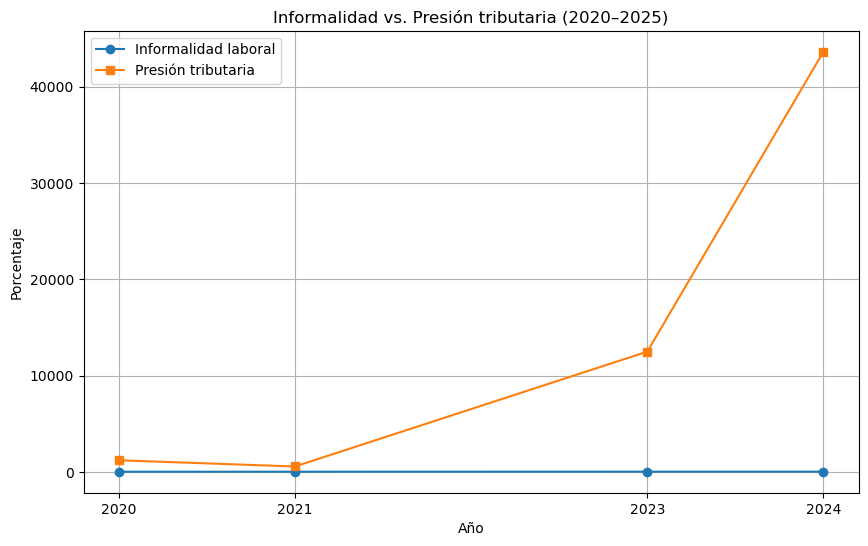

In [66]:
#📌 4) Gráfico comparativo de informalidad

#Informalidad vs. Presión tributaria

plt.figure(figsize=(10,6))

plt.plot(df_master["anio"], df_master["tasa_informalidad"], "-o", label="Informalidad laboral")
plt.plot(df_master["anio"], df_master["presion_tributaria"], "-s", label="Presión tributaria")

plt.title("Informalidad vs. Presión tributaria (2020–2025)")
plt.xlabel("Año")
plt.ylabel("Porcentaje")
plt.grid(True)
plt.legend()
plt.xticks(df_master["anio"])
plt.show()

🧠 Interpretación sugerida
Mirá si la tasa de informalidad sube o baja cuando la presión tributaria crece o desciende (o si no hay relación clara).

In [69]:
#🔎 1️⃣ Cambio estructural: Antes y después del shock 2020

#Creamos una variable categórica:

df_master["periodo"] = df_master["anio"].apply(
    lambda x: "Shock Pandemia (2020)" if x == 2020 else "Post-pandemia (2021-2025)"
)

In [71]:
df_master.groupby("periodo")[[
    "tasa_empleo_formal",
    "tasa_informalidad",
    "presion_tributaria"
]].mean()

,tasa_empleo_formal,tasa_informalidad,presion_tributaria
periodo,,,
Post-pandemia (2021-2025),64.983333,35.016667,18901.376021
Shock Pandemia (2020),69.775000,30.225000,1218.002608


🎯 Esto te permite decir:

"El shock inicial redujo artificialmente la informalidad, pero la presión tributaria no cayó en la misma magnitud / sí cayó / se sostuvo..."

Eso es análisis estructural.

In [74]:
#📈 2️⃣ Correlación real entre variables

#No solo visual — numérica:

df_master[[
    "tasa_empleo_formal",
    "tasa_informalidad",
    "presion_tributaria",
    "pib_total"
]].corr()

,tasa_empleo_formal,tasa_informalidad,presion_tributaria,pib_total
tasa_empleo_formal,1.000000,-1.000000,-0.728319,-0.932006
tasa_informalidad,-1.000000,1.000000,0.728319,0.932006
presion_tributaria,-0.728319,0.728319,1.000000,0.528655
pib_total,-0.932006,0.932006,0.528655,1.000000


Interpretación para clase:

Correlación negativa fuerte → posible relación inversa

Correlación débil → fenómeno más complejo

Cuidado: muestra pequeña (6 años)

Eso demuestra criterio metodológico.

In [77]:
#📊 3️⃣ Elasticidad simple

#¿Cuando cambia 1% la presión tributaria cuánto cambia la informalidad?

df_master["var_presion"] = df_master["presion_tributaria"].pct_change()
df_master["var_informalidad"] = df_master["tasa_informalidad"].pct_change()

df_master[["anio","var_presion","var_informalidad"]]

,anio,var_presion,var_informalidad
0,2020,NaN,NaN
1,2021,-0.529263,0.077750
2,2023,20.796813,0.112817
3,2024,2.491397,-0.000690


In [79]:
elasticidad = (
    df_master["var_informalidad"] /
    df_master["var_presion"]
)

elasticidad.mean()

-0.04725163274277078

In [81]:
#🧩 4️⃣ Categorizar niveles de presión tributaria

#Creamos categorías:

df_master["nivel_presion"] = pd.cut(
    df_master["presion_tributaria"],
    bins=3,
    labels=["Baja", "Media", "Alta"]
)

df_master[["anio","presion_tributaria","nivel_presion"]]

,anio,presion_tributaria,nivel_presion
0,2020,1218.002608,Baja
1,2021,573.358925,Baja
2,2023,12497.397518,Baja
3,2024,43633.371618,Alta


In [83]:
df_master.groupby("nivel_presion")["tasa_informalidad"].mean()

C:\Users\brent\AppData\Local\Temp\ipykernel_856\2684954670.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_master.groupby("nivel_presion")["tasa_informalidad"].mean()


nivel_presion
Baja     33.016667
Media          NaN
Alta     36.225000
Name: tasa_informalidad, dtype: float64

🎓 Esto permite discutir:

¿Mayor presión = mayor informalidad?

¿O no hay patrón claro?

¿Influye más el ciclo económico que la carga tributaria?

In [85]:
#📉 5️⃣ Modelo simple (nivel diplomatura)

#Una regresión lineal básica:

import numpy as np
from sklearn.linear_model import LinearRegression

X = df_master[["presion_tributaria"]]
y = df_master["tasa_informalidad"]

modelo = LinearRegression()
modelo.fit(X, y)

print("Coeficiente:", modelo.coef_[0])
print("Intercepto:", modelo.intercept_)
print("R²:", modelo.score(X, y))

Coeficiente: 0.00010651959779287388
Intercepto: 32.27628948443375
R²: 0.5304480615133389


Interpretación:

Coeficiente positivo → mayor presión asociada a mayor informalidad

R² bajo → relación débil

R² medio/alto → relación explicativa

🧠 Ahora viene lo interesante (conceptual)

En 2020 ocurre algo clave:

Caída formalidad

Caída actividad

Pero la presión tributaria puede mantenerse si:

Suben impuestos indirectos

Hay efecto nominal (inflación)

Cambia composición impositiva

Eso abre discusión sobre:

"¿La presión tributaria refleja realmente carga económica o efecto nominal?"

Eso es nivel diplomatura real.